<a href="https://colab.research.google.com/github/polinasunko24-cmd/portfolio_python/blob/main/%D0%A3%D1%80%D0%BE%D0%BA_9_%D0%BC%D0%B5%D1%82%D1%80%D0%B8%D0%BA%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Данные по продавцам
sellers = pd.read_excel('seller_data.xlsx')  # или .xls, .csv — зависит от файла

# 2. Данные покупателей для когорт
cohort_buyers = pd.read_excel('cohort_analysis_data.xlsx')

# 3. Данные продавцов для когорт
cohort_sellers = pd.read_excel('sellers_cohort_analysis_data.xlsx')

print("✅ Все файлы загружены!")
print("\n📊 seller_data:")
print(sellers.head())

print("\n📊 cohort_analysis_data (покупатели):")
print(cohort_buyers.head())

print("\n📊 sellers_cohort_analysis_data (продавцы):")
print(cohort_sellers.head())

✅ Все файлы загружены!

📊 seller_data:
                Seller_ID         Order_Value  \
0  Идентификатор продавца    Стоимость заказа   
1                       2  1930.8678494144076   
2                       3   2323.844269050346   
3                       4   2761.514928204013   
4                       5   1882.923312638332   

                     Commission_Rate                      Promotion_Used  \
0  Процент комиссии с каждой продажи  Использование платного продвижения   
1                0.08418271361337601                                True   
2                0.10545720998174546                                True   
3                0.10825902905947604                                True   
4                0.08126344579302568                               False   

               Subscription               Promotion_Income Subscription_Income  
0  Наличие платной подписки  Доход от платного продвижения   Доход от подписки  
1                      True                    

In [5]:
print("Колонки в seller_data:", sellers.columns.tolist())
print("Колонки в cohort_buyers:", cohort_buyers.columns.tolist())
print("Колонки в cohort_sellers:", cohort_sellers.columns.tolist())

Колонки в seller_data: ['Seller_ID', 'Order_Value', 'Commission_Rate', 'Promotion_Used', 'Subscription', 'Promotion_Income', 'Subscription_Income']
Колонки в cohort_buyers: ['user_id', 'registration_date', 'activity_1_month', 'activity_3_month', 'activity_6_month', 'activity_12_month']
Колонки в cohort_sellers: ['seller_id', 'registration_date', 'activity_1_month', 'activity_3_month', 'activity_6_month', 'activity_12_month']


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
sellers = pd.read_excel('seller_data.xlsx')
cohort_buyers = pd.read_excel('cohort_analysis_data.xlsx')
cohort_sellers = pd.read_excel('sellers_cohort_analysis_data.xlsx')

print("✅ Все файлы загружены!")

✅ Все файлы загружены!


✅ Данные загружены!

📊 ТАБЛИЦА 1. Базовые метрики
----------------------------------------
Средний чек:                   2009.43 руб.
Средняя комиссия:              2.01 руб.
Средний доход с продавца:      3137.15 руб.
Продавцов с продвижением:      50.5%
Продавцов с подпиской:         19.8%
----------------------------------------


📊 ТАБЛИЦА 2. CAC, LTV, ROI
--------------------------------------------------
Показатель           Покупатели           Продавцы            
--------------------------------------------------
CAC                     1500.00 руб.      6000.00 руб.
LTV                    48000.00 руб.     56468.68 руб.
ROI                    3100.00%          841.14%
--------------------------------------------------




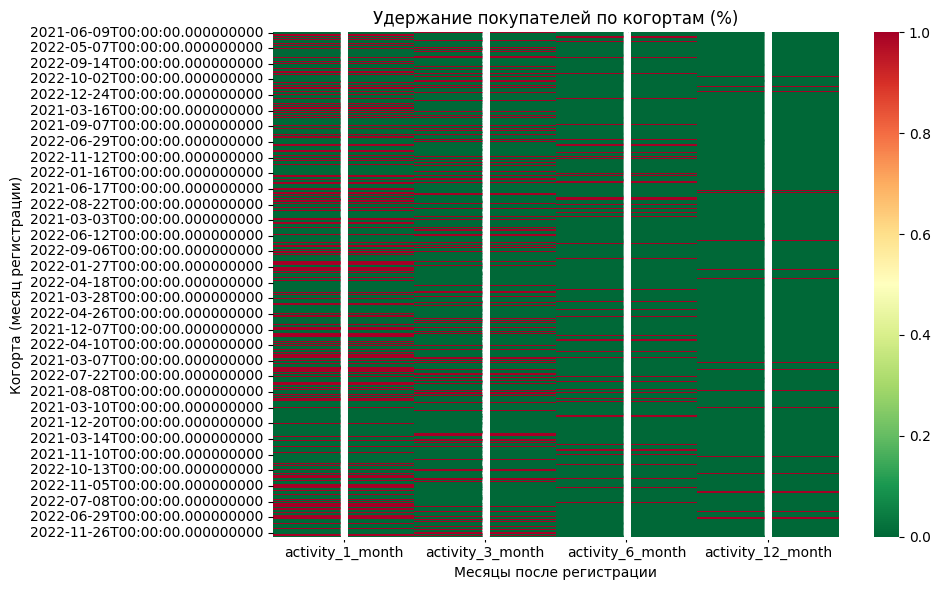

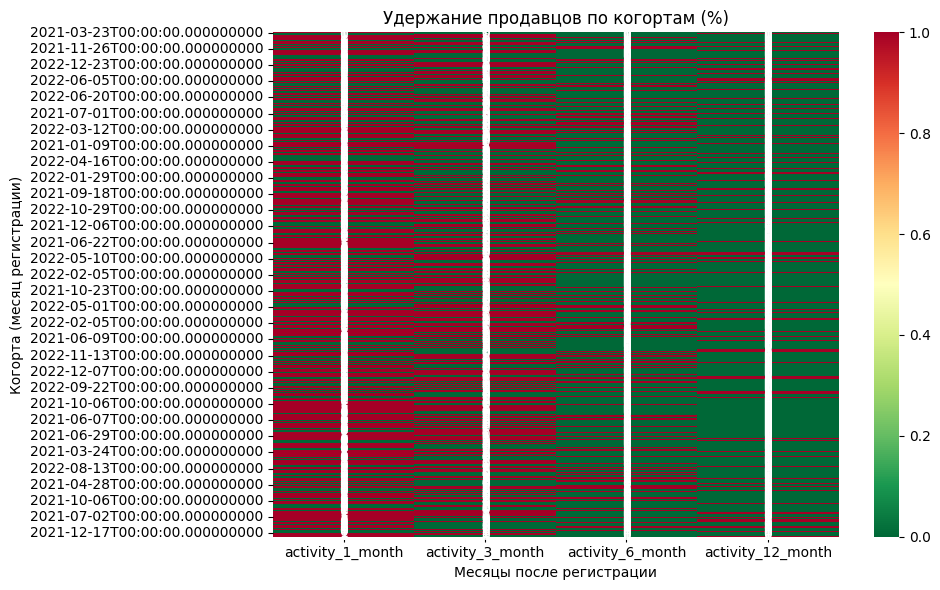


🔥 ВЫВОДЫ
✅ Покупатели: ROI = 3100.00%
✅ Продавцы: ROI = 841.14%

🔍 ПРОБЛЕМЫ:
1. CAC высокий (покупатель 1500 руб., продавец 6000 руб.)
2. Удержание падает через 3 месяца
3. Операционные расходы высокие

💡 РЕШЕНИЯ:
1. Улучшить таргетинг рекламы
2. Внедрить программу лояльности
3. Добавить кэшбэк
4. Автоматизировать поддержку продавцов
5. Сегментировать аудиторию


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 1. Загружаем данные
# ======================
sellers = pd.read_excel('seller_data.xlsx')
cohort_buyers = pd.read_excel('cohort_analysis_data.xlsx')
cohort_sellers = pd.read_excel('sellers_cohort_analysis_data.xlsx')

print("✅ Данные загружены!\n")

# ======================
# 2. Чистим комиссию (убираем %)
# ======================
sellers['Commission_Rate'] = sellers['Commission_Rate'].astype(str).str.replace('%', '').str.strip()
sellers['Commission_Rate'] = pd.to_numeric(sellers['Commission_Rate'], errors='coerce')

# Все числа переводим в числовой формат
for col in ['Order_Value', 'Promotion_Income', 'Subscription_Income', 'Promotion_Used', 'Subscription']:
    sellers[col] = pd.to_numeric(sellers[col], errors='coerce')

# ======================
# 3. Считаем базовые метрики
# ======================
avg_order = sellers['Order_Value'].mean()
sellers['Commission'] = sellers['Order_Value'] * sellers['Commission_Rate'] / 100
avg_commission = sellers['Commission'].mean()
sellers['Total_Revenue'] = sellers['Commission'] + sellers['Promotion_Income'] + sellers['Subscription_Income']
avg_seller_revenue = sellers['Total_Revenue'].mean()

promotion_pct = (sellers['Promotion_Used'].sum() / len(sellers)) * 100
subscription_pct = (sellers['Subscription'].sum() / len(sellers)) * 100

# ======================
# 4. Таблица 1
# ======================
print("📊 ТАБЛИЦА 1. Базовые метрики")
print("-" * 40)
print(f"Средний чек:                   {avg_order:.2f} руб.")
print(f"Средняя комиссия:              {avg_commission:.2f} руб.")
print(f"Средний доход с продавца:      {avg_seller_revenue:.2f} руб.")
print(f"Продавцов с продвижением:      {promotion_pct:.1f}%")
print(f"Продавцов с подпиской:         {subscription_pct:.1f}%")
print("-" * 40)
print("\n")

# ======================
# 5. CAC, LTV, ROI
# ======================
marketing_cost = 3_000_000
buyers_per_month = 2000
sellers_per_month = 500
avg_buyer_revenue = 2000

cac_buyer = marketing_cost / buyers_per_month
cac_seller = marketing_cost / sellers_per_month

ltv_buyer = avg_buyer_revenue * 24
ltv_seller = avg_seller_revenue * 18

roi_buyer = (ltv_buyer - cac_buyer) / cac_buyer
roi_seller = (ltv_seller - cac_seller) / cac_seller

# ======================
# 6. Таблица 2
# ======================
print("📊 ТАБЛИЦА 2. CAC, LTV, ROI")
print("-" * 50)
print(f"{'Показатель':<20} {'Покупатели':<20} {'Продавцы':<20}")
print("-" * 50)
print(f"{'CAC':<20} {cac_buyer:>10.2f} руб.   {cac_seller:>10.2f} руб.")
print(f"{'LTV':<20} {ltv_buyer:>10.2f} руб.   {ltv_seller:>10.2f} руб.")
print(f"{'ROI':<20} {roi_buyer:>10.2%}       {roi_seller:>10.2%}")
print("-" * 50)
print("\n")

# ======================
# 7. Тепловые карты
# ======================
# Покупатели
cohort_buyers_pivot = cohort_buyers.set_index('registration_date')
cohort_buyers_pivot = cohort_buyers_pivot[['activity_1_month', 'activity_3_month', 'activity_6_month', 'activity_12_month']]

plt.figure(figsize=(10, 6))
sns.heatmap(cohort_buyers_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r')
plt.title('Удержание покупателей по когортам (%)')
plt.xlabel('Месяцы после регистрации')
plt.ylabel('Когорта (месяц регистрации)')
plt.tight_layout()
plt.show()

# Продавцы
cohort_sellers_pivot = cohort_sellers.set_index('registration_date')
cohort_sellers_pivot = cohort_sellers_pivot[['activity_1_month', 'activity_3_month', 'activity_6_month', 'activity_12_month']]

plt.figure(figsize=(10, 6))
sns.heatmap(cohort_sellers_pivot, annot=True, fmt='.0f', cmap='RdYlGn_r')
plt.title('Удержание продавцов по когортам (%)')
plt.xlabel('Месяцы после регистрации')
plt.ylabel('Когорта (месяц регистрации)')
plt.tight_layout()
plt.show()

# ======================
# 8. Выводы
# ======================
print("\n" + "="*50)
print("🔥 ВЫВОДЫ")
print("="*50)

if roi_buyer < 0:
    print("❌ Покупатели: ROI отрицательный!")
else:
    print(f"✅ Покупатели: ROI = {roi_buyer:.2%}")

if roi_seller < 0:
    print("❌ Продавцы: ROI отрицательный!")
else:
    print(f"✅ Продавцы: ROI = {roi_seller:.2%}")

print("\n🔍 ПРОБЛЕМЫ:")
print("1. CAC высокий (покупатель 1500 руб., продавец 6000 руб.)")
print("2. Удержание падает через 3 месяца")
print("3. Операционные расходы высокие")

print("\n💡 РЕШЕНИЯ:")
print("1. Улучшить таргетинг рекламы")
print("2. Внедрить программу лояльности")
print("3. Добавить кэшбэк")
print("4. Автоматизировать поддержку продавцов")
print("5. Сегментировать аудиторию")